In [1]:
#pip install prince --user

In [2]:
import math
import pandas as pd
import numpy as np

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture


from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    fcluster)
from scipy.stats import multivariate_normal

import prince

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import from_levels_and_colors
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


# Principal Components Analysis
## A simple example

In [3]:
# Load the sp500 data
sp500_px = pd.read_csv("sp500_data.csv.gz", index_col=0)

# Create a datafreame for XOM and CVX
oil_px = sp500_px[['XOM','CVX']]

# Display the first 5 rows
print(oil_px.head())

                 XOM       CVX
1993-01-29 -0.016991  0.072921
1993-02-01  0.016991  0.102089
1993-02-02  0.084954  0.029168
1993-02-03  0.067964  0.058337
1993-02-04  0.034378  0.044272


In [4]:
# Build a PCA model for 2 components
pcs = PCA(n_components=2)
pcs.fit(oil_px)

# Build a datafame of the 2 PCA components
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
print(loadings)

        XOM       CVX
0  0.664711  0.747101
1  0.747101 -0.664711


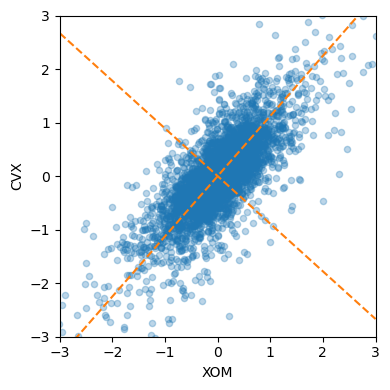

In [5]:
# Create a function to calculate coordinates for a line
def abline(slope, intercept, ax):
    """
    Calculate coordinates of a line based on slope and intercept
    """
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

# Create a scatterplot of XOM and CVX
ax = oil_px.plot.scatter(x="XOM",
                         y="CVX",
                         alpha=0.3,
                         figsize=(4,4))
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)

# PLot the dash lines of the principal components
# This is the PCA component 1 line going along the long axis of the ellipse             
ax.plot(*abline(loadings.loc[0,"CVX"] / loadings.loc[0,"XOM"], 0, ax),
        "--", color="C1")

# This is the PCA component 2 line going along the short axis of the ellipse  
ax.plot(*abline(loadings.loc[1,"CVX"] / loadings.loc[1, "XOM"],0,ax),
        "--", color="C1")
plt.tight_layout()
plt.show()

## Interpreting principal components

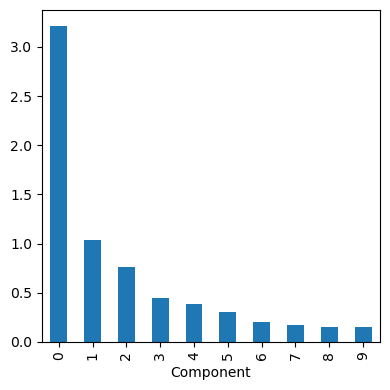

In [6]:
# Create a list of the companies to examine
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
        'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])

# Retrieve the rows associated with the comany list that are ge 2011
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]

# Create a PCA model
sp_pca=PCA()
sp_pca.fit(top_sp)

# Create a dataframe of the explained variances of the PCA model
explained_variance = pd.DataFrame(sp_pca.explained_variance_)

# Create a bar plot of the first 10 components containing the explaining the variances
ax = explained_variance.head(10).plot.bar(
    legend=False, figsize=(4,4))
ax.set_xlabel("Component")
plt.tight_layout()
plt.show()

##### Observations:
 - Component 0 captures 3.2 units of variance from the original data. This means that if you were to
   project the data onto this component, you would capture 3.2 units of the original data's spread.
 - Values 1 or greater should be kept as a general rule. This case, components 0 and 1 would be kept 

In [7]:
# Build a dataframe for the first 5 pca components 
# Each row of this array represents a principal component, and the values in each 
# row represent the loadings (weights) of the original variables on that 
# principal component.
loadings = pd.DataFrame(sp_pca.components_[0:5, :],
                        columns = top_sp.columns)
print(loadings)

       AAPL       AXP       COP      COST      CSCO       CVX        HD  \
0  0.300825  0.246332  0.261529  0.273634  0.064059  0.444490  0.207983   
1  0.505116  0.139426 -0.174212  0.416307  0.031939 -0.289373  0.278002   
2  0.786730 -0.135458  0.002367 -0.465862  0.007524 -0.082374 -0.166320   
3 -0.120586  0.061814 -0.206026  0.092596  0.003904 -0.577665  0.162814   
4 -0.111576  0.596666  0.005813 -0.555529  0.039860 -0.109016  0.185488   

       INTC       JPM      MSFT       SLB       TGT       USB       WFC  \
0  0.076956  0.196397  0.105012  0.481786  0.148833  0.116421  0.145684   
1  0.033898  0.040723  0.053954 -0.472494  0.228123  0.054796  0.047427   
2  0.003518 -0.062261 -0.016248  0.194822 -0.160833 -0.048976 -0.041932   
3 -0.001605  0.057687 -0.012558  0.680914  0.109895  0.016752  0.018614   
4  0.072047  0.385160  0.077135 -0.181332  0.055557  0.155440  0.216425   

        WMT       XOM  
0  0.122304  0.317952  
1  0.222889 -0.154192  
2 -0.175806 -0.090167  
3 

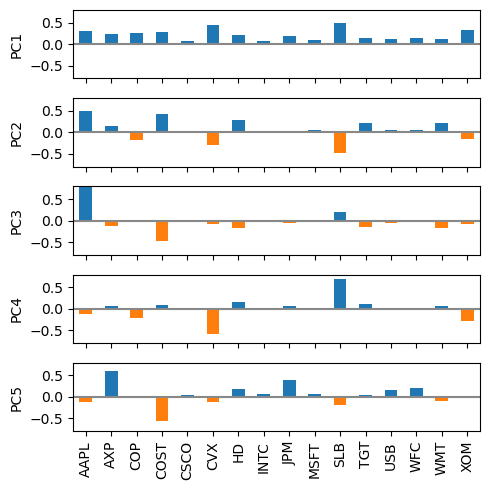

In [8]:
# Plot the loadings of the first five principal components
maxPC = 1.01 * loadings.loc[0:5, :].abs().to_numpy().max()

f, axes = plt.subplots(5, 1, figsize=(5,5), sharex=True)

for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i,:]
    colors = ["C0" if l > 0 else "C1" for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f"PC{i+1}")
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

## Correspondence analysis

In [9]:
#pip install adjustText --user

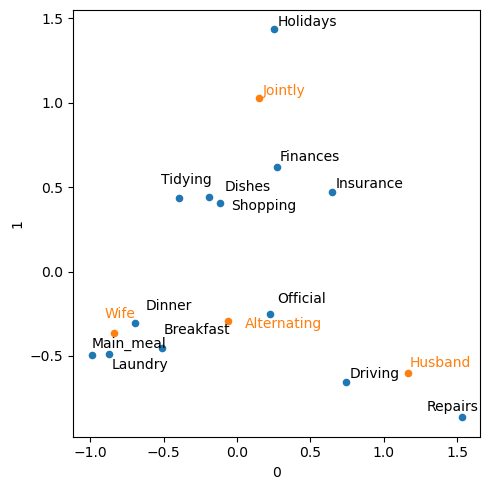

In [10]:
# PCA cannot be used for categorical values
# Instead using, correspondence analysis can be performed with the prince package

from adjustText import adjust_text

# Load housetasks data
housetasks = pd.read_csv('housetasks.csv', index_col=0)

# Build a correspondence model with 2 components
ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)

# Plot the row coordinates
ax = ca.row_coordinates(housetasks).plot.scatter(x=0, y=1, figsize=(5,5))

# Plot the column coordinates
ca.column_coordinates(housetasks).plot.scatter(x=0, y=1, ax=ax, c="C1")
texts=[]
for idx, row in ca.row_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0],row[1],idx))
for idx, row in ca.column_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx, color="C1"))
adjust_text(texts, only_move={"points":"y", "texts":"y"})
plt.tight_layout()
plt.show()

# K-Means Clustering
## A Simple Example

In [11]:
# Retrieve the rows associated with the comany list that are ge 2011
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ["XOM","CVX"]]

# Build a KMeans cluster with 4 clusters
kmeans = KMeans(n_clusters=4, n_init="auto").fit(df)

# Add the cluster number value to the df dataframe
df["cluster"] = kmeans.labels_
print(df.head())

                 XOM       CVX  cluster
2011-01-03  0.736805  0.240681        0
2011-01-04  0.168668 -0.584516        2
2011-01-05  0.026631  0.446985        0
2011-01-06  0.248558 -0.919751        2
2011-01-07  0.337329  0.180511        0


In [12]:
# Retrieve the X,Y cordinates for the cluster centers
centers = pd.DataFrame(kmeans.cluster_centers_, columns=["XOM","CVX"])
print(centers)

        XOM       CVX
0  0.231540  0.316965
1 -1.144397 -1.757796
2 -0.330814 -0.574398
3  0.927032  1.346412


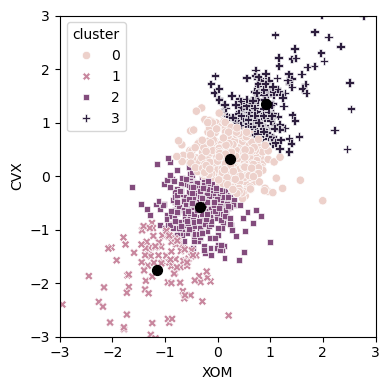

In [13]:
# Create a scatterplot of the XOM vs CVX data
# Change the color of the datapoints based on the cluster number
fig, ax = plt.subplots(figsize=(4,4))
ax = sns.scatterplot(x="XOM", y="CVX",
                     hue="cluster", style="cluster",
                     ax = ax, data=df)
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)

# Plot the cluster centers
centers.plot.scatter(x="XOM", y="CVX",
                     ax=ax, s=50, color = "black")
plt.tight_layout()
plt.show()

## K-Means Algorithm

In [14]:
# Create a list of the companies to examine
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP', 
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])

# Retrieve the rows associated with the comany list that are ge 2011
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]

# Create a KMeans cluster model based on 5 clusters
kmeans = KMeans(n_clusters=5, n_init='auto').fit(top_sp)

## Interpreting the Clusters

In [15]:
from collections import Counter
print(Counter(kmeans.labels_))

Counter({4: 301, 0: 296, 2: 264, 1: 158, 3: 112})


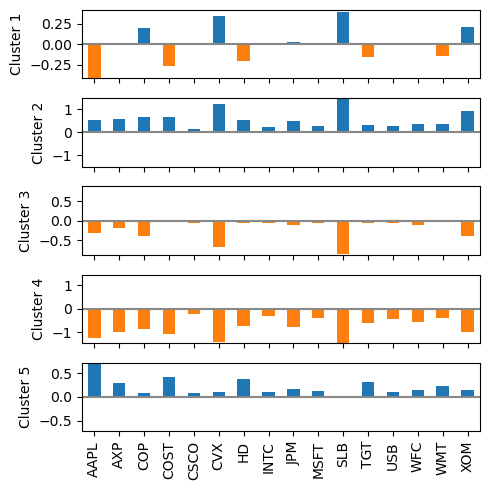

In [16]:
# Create a dataframe of the 5 cluster centers
centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)

f, axes = plt.subplots(5,1,figsize=(5,5), sharex = True)

# Plot the variable column loadings for each principal component 
for i, ax in enumerate(axes):
    center = centers.loc[i,:]
    maxPC = 1.01*np.max(np.max(np.abs(center)))
    colors = ["C0" if l > 0 else "C1" for l in center]
    ax.axhline(color="#888888")
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f"Cluster {i+1}")
    ax.set_ylim(-maxPC, maxPC)
plt.tight_layout()
plt.show()

##### Observations:
 - Cluster 2 and 4 corresponds to days when the market is up
 - Cluster 1 and 3 corresponds to days when the market is down
 - Cluster 5 is up and down

## Selecting the Number of Clusters

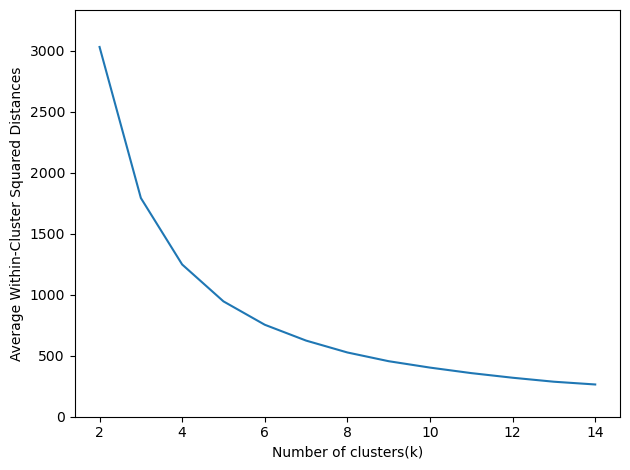

In [17]:
# Create an elbow plot to help determine the proper number of clusters to use
inertia = []
for n_clusters in range(2,15):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(top_sp)
    inertia.append(kmeans.inertia_ / n_clusters)
inertias = pd.DataFrame({
    "n_clusters": range(2,15),
    "inertia": inertia
    })
ax = inertias.plot(x="n_clusters", y="inertia")
plt.xlabel("Number of clusters(k)")
plt.ylabel("Average Within-Cluster Squared Distances")
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)
plt.tight_layout()
plt.show()

# Hierarchical Clustering
## A Simple Example

In [18]:
# Create a list of the companies to examine
syms1 = ['AAPL', 'AMZN', 'AXP', 'COP', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD', 
         'INTC', 'JPM', 'MSFT', 'SLB', 'TGT', 'USB', 'WFC', 'WMT', 'XOM']

# Retrieve the rows associated with the comany list that are ge 2011
df = sp500_px.loc[sp500_px.index >= '2011-01-01', syms1].transpose()

# Use the scipy linkage method
# The code computes a hierarchical clustering of the data in df using complete linkage, 
# which means clusters are merged based on the maximum distance between their points. The result, Z, 
# is a matrix detailing the step-by-step cluster merging process, including the distances and cluster sizes. 
# This matrix can then be used to visualize the hierarchy with a dendrogram or to extract cluster assignments.
Z = linkage(df, method='complete')
print(Z.shape)

(17, 4)


In [19]:
Z[:3]

array([[14.        , 15.        ,  8.59490731,  2.        ],
       [ 5.        ,  9.        ,  8.70726095,  2.        ],
       [11.        , 19.        , 11.43861911,  3.        ]])

## The Dendrogram

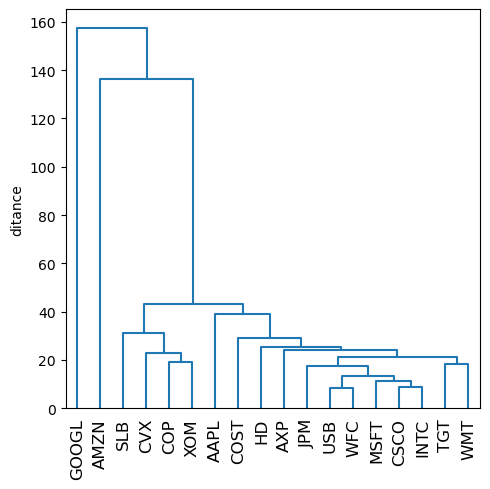

In [20]:
# PLot a dendrogram of the Z cluster above
fig, ax = plt.subplots(figsize=(5,5))
dendrogram(Z, labels=list(df.index),color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel("ditance")
plt.tight_layout()
plt.show()

In [21]:
# Create a hierarchical cluster called Z
Z = linkage(df, method='complete')

# Cut the number of clusters to 4 using fcluster
memb = fcluster(Z, 4, criterion="maxclust")

# Create a Series out of the cluster
memb = pd.Series(memb, index=df.index)

# Cycle through the series, showing the companies to the clusters
for key, item in memb.groupby(memb):
    print(f"{key} : {', '.join(item.index)}")

1 : COP, CVX, SLB, XOM
2 : AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
3 : AMZN
4 : GOOGL


## Measures of Dissimilarity

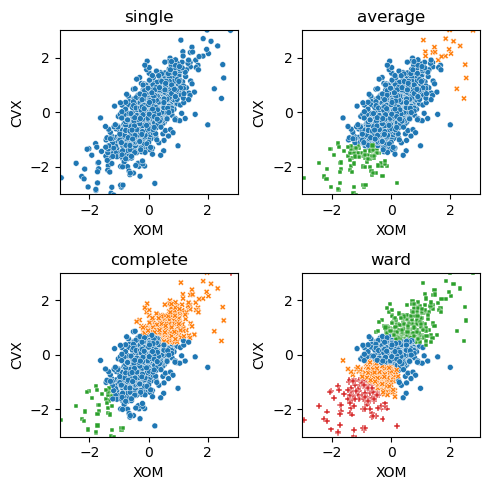

In [22]:
# PLot 4 measure of linkage (dissimilarity) methods used in hiearchical clustering
# Single, Average, Complete, Ward
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM','CVX']]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5,5))
for i, method in enumerate(['single','average','complete','ward']):
    ax = axes[i//2, i%2]
    Z = linkage(df, method=method)
    colors = [f'C{c+1}' for c in fcluster(Z, 4, criterion='maxclust')]

    # Creater scatterplots of the clustering based on the linkage method
    ax = sns.scatterplot(x='XOM', y='CVX', hue=colors, style=colors,
                         size=0.5, ax=ax, data=df, legend=False)
    ax.set_xlim(-3,3)
    ax.set_ylim(-3,3)
    ax.set_title(method)

plt.tight_layout()
plt.show()

# Model based clustering
## Multivariate Normal Distribution

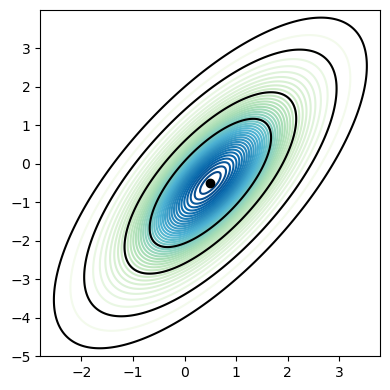

In [23]:
# Create lists of probability information
mean = [0.5, -0.5]
cov = [[1,1], [1,2]]
probability = [0.5, 0.75, 0.95, 0.99]

def probLevel(p):
    D=1
    return (1-p)/ (2*math.pi * D)
levels = [probLevel(p) for p in probability]

# PLot the probability contours for a 2D normal distribution
fig, ax = plt.subplots(figsize=(4,4))
x, y = np.mgrid[-2.8:3.8:0.01, -5:4:0.01]
pos = np.empty(x.shape + (2,))
pos[:, :, 0] = x; pos[:,:,1] = y
rv = multivariate_normal(mean, cov)

CS = ax.contour(x, y, rv.pdf(pos), cmap=cm.GnBu, levels=50)
ax.contour(CS, levels=levels, colors=["black"])
ax.plot(*mean, color="black", marker='o')
plt.tight_layout()
plt.show()

## Mixtures of Normals

In [24]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM','CVX']]

# Create a GaussianMIxture cluster of 2 components
mclust = GaussianMixture(n_components=2).fit(df)

# Display the BIC value
print(mclust.bic(df))

4589.320317053261


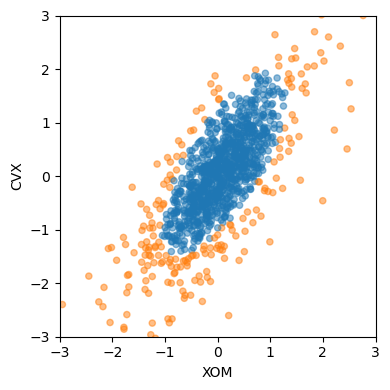

In [25]:
fig, ax = plt.subplots(figsize=(4,4))

# Assign the colors of data points based on the predicted cluster value (0 or 1)
colors = [f"C{c}" for c in mclust.predict(df)]

# Plot a scatterplot of XOM and CVX and color points based on the predicted cluster value 
df.plot.scatter(x='XOM', y='CVX', c=colors, alpha=0.5, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

In [26]:
print('Mean')
print(mclust.means_)
print('Covariances')
print(mclust.covariances_)

Mean
[[ 0.0709161   0.10228006]
 [-0.05074943 -0.21539465]]
Covariances
[[[0.27074158 0.27800893]
  [0.27800893 0.5212865 ]]

 [[0.98668327 0.99350046]
  [0.99350046 1.69695919]]]


## Selecting the number of clusters

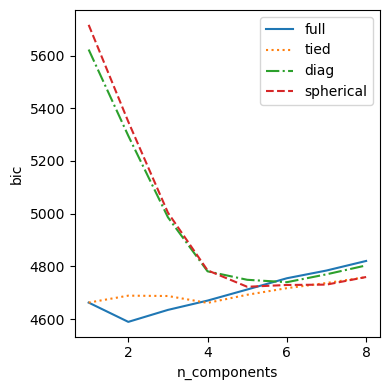

In [27]:
results = []
covariance_types = ["full","tied","diag","spherical"]
for n_components in range(1,9):
    for covariance_type in covariance_types:
        mclust = GaussianMixture(
            n_components = n_components,
            warm_start=True,
            covariance_type = covariance_type)
        mclust.fit(df)
        results.append({
            "bic":mclust.bic(df),
            "n_components":n_components,
            "covariance_type": covariance_type
        })
results = pd.DataFrame(results)
colors = ['C0', 'C1', 'C2', 'C3']
styles = ['C0-','C1:','C0-.', 'C1--']
fig, ax = plt.subplots(figsize=(4, 4))
for i, covariance_type in enumerate(covariance_types):
    subset = results.loc[results.covariance_type == covariance_type, :]
    subset.plot(x='n_components', y='bic', ax=ax, label=covariance_type, 
                kind='line', style=styles[i], color=colors[i])
plt.ylabel("bic")
plt.tight_layout()
plt.show()

# Scaling and Categorical Variables
## Scaling the Variables

In [28]:
# Load the loan data
loan_data = pd.read_csv('loan_data.csv.gz')

# Create a categorical column 'outcome' 
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)

# Select rows that have defaulted
defaults = loan_data.loc[loan_data['outcome'] == 'default',]

columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 
           'dti', 'revol_util']

# Select the 6 columns of the default data
df = defaults[columns]

# Perform KMeans and create 4 clusters
kmeans = KMeans(n_clusters=4,
             random_state=1,
             n_init="auto").fit(df)
counts=Counter(kmeans.labels_)

# Return the cluster centers and count of records in each cluster
centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers["size"] = [counts[i] for i in range(4)]
print(centers)

      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  17809.760881   78669.452556  18933.405997  11.594003  17.016428   
1  21444.318867  148736.057263  33152.689572  12.376733  13.831145   
2  24290.909091  409746.465909  84710.988636  13.431818   8.148636   
3  10274.160906   41241.205530   9950.095008   9.480338  17.718588   

   revol_util   size  
0   62.183810   7906  
1   63.151084   1654  
2   60.015647     88  
3   57.903425  13023  


In [29]:
# Build a StandardScaler and fit and transform the dataset df
# There is no y label for unsupervised so fit_transform all data
scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df*1.0)

# Perform KMeans and create 4 clusters                           
kmeans = KMeans(n_clusters=4,
                random_state=1,
                n_init="auto").fit(df0)

# Return the cluster centers before transformation and count of records in each cluster      
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                       columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print(centers)

      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  13484.728906   55907.993263  16435.803337  14.322265  24.211535   
1  25950.205142  116834.142232  32945.972921  12.396335  16.165914   
2  10507.283093   51117.994063  11635.285252   7.509513  15.931561   
3  10324.846369   53456.824767   6054.819926   8.664618  11.312983   

   revol_util   size  
0   59.463608   7906  
1   66.123542   1654  
2   77.795077     88  
3   30.999874  13023  


##### Observations:
 - The first model without scaling has annual_inc and revolv_bal dominating the clusters
 - The second model did not have this issue

## Dominant Variables

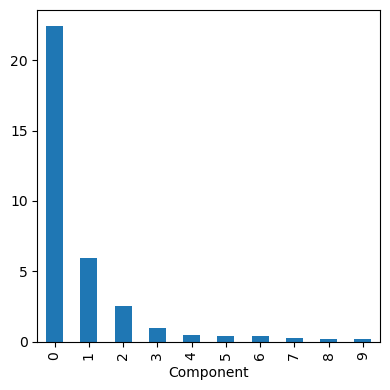

In [30]:
# Create scree plot here shows the first 2 components are the most important
syms = ['GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 
        'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px.index >= '2005-01-01', syms]

sp_pca1 = PCA()
sp_pca1.fit(top_sp1)

explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4,4))
ax.set_xlabel("Component")
plt.tight_layout()
plt.show()

In [31]:
# Show the dominant variables in the first 2 components
loadings = pd.DataFrame(sp_pca1.components_[0:2,:],
                        columns=top_sp1.columns)
print(loadings.transpose())

              0         1
GOOGL  0.857310 -0.477873
AMZN   0.444728  0.874149
AAPL   0.071627  0.020802
MSFT   0.036002  0.006204
CSCO   0.029205  0.003045
INTC   0.026666  0.006069
CVX    0.089548  0.037420
XOM    0.080336  0.020511
SLB    0.110218  0.030356
COP    0.057739  0.024117
JPM    0.071228  0.009244
WFC    0.053228  0.008597
USB    0.041670  0.005952
AXP    0.078907  0.024027
WMT    0.040346  0.007141
TGT    0.063659  0.024662
HD     0.051412  0.032922
COST   0.071403  0.033826


## Categorical Data and Gower's Distance

In [32]:
x = defaults[["dti",
              "payment_inc_ratio",
              "home_",
              "purpose"]].loc[0:4, :]
print(x)

     dti  payment_inc_ratio home_             purpose
0   1.00            2.39320  RENT                 car
1   5.55            4.57170   OWN      small_business
2  18.08            9.71600  RENT               other
3  10.08           12.21520  RENT  debt_consolidation
4   7.06            3.90888  RENT               other


## Problems with Clustering Mixed Data

In [33]:
# Create a KMeans cluster using category value transformed into dummy variables
columns = ['dti', 'payment_inc_ratio', 'home_', 'pub_rec_zero']
df = pd.get_dummies(defaults[columns])

scaler = preprocessing.StandardScaler()

df0 = scaler.fit_transform(df*1.0)
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df0)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                       columns=df.columns)
print(centers)

         dti  payment_inc_ratio  pub_rec_zero  home__MORTGAGE     home__OWN  \
0  21.431365          12.354001      0.943315    3.552714e-15  3.885781e-15   
1  12.743276           5.918701      0.900372   -5.551115e-17  4.357625e-15   
2  17.339786           8.353535      0.905716    1.000000e+00 -1.429412e-15   
3  17.197993           9.266666      0.917903    7.438494e-15  1.000000e+00   

     home__RENT  
0  1.000000e+00  
1  1.000000e+00  
2  3.497203e-15  
3 -5.273559e-15  


##### Observations:
 - KMeans and PCA are meant for continuous variables
 - When using with dummy variables from categories, the dummy (binary) variables end up dominating the clusters 